In [1]:
#importing some necessary files with thr|owing any error
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import sys
    import os
    import math
except:
    print("An error occurred")
else:
    print("Everything is just fine")

Everything is just fine


In [2]:
#For scikit-learn module files
try:
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, confusion_matrix, classification_report
except:
    print("An error occurred")
else:
    print("Fine")
def PANDAS_to_NUMPY(dataset):
    x = dataset.iloc[:,:-1:].values
    y = dataset.iloc[::,-1].values
    return x,y
def DATA_SPLIT(x,y,size=0.2,state=42):
    return train_test_split(x,y,test_size=size,random_state=state)
SC = StandardScaler()
KNN = KNeighborsClassifier(n_neighbors=5)
LR = LogisticRegression(max_iter=1000)

Fine


In [3]:
#For reading csv
def data_frame(file):
    path_confirm = os.path.exists(file)
    details = os.path.splitext(file)
    name,extension = details
    if path_confirm and extension.lower() == '.csv':
        df = pd.read_csv(file)
        return df
    else:
        print("Sorry but we need csv file")
        return None

In [4]:
#creating datafram from the given dataset
DiseaseData = data_frame("heart.csv")

In [5]:
#checking datafram last 10 rows
DiseaseData.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [6]:
DiseaseData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
DiseaseData.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
print(DiseaseData.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [9]:
#checking the total number of duplicated rows
print(len(DiseaseData[DiseaseData.duplicated()==True]))

723


In [10]:
#clearing the duplicated data
TempDiseaseData = DiseaseData[DiseaseData.duplicated()==False]

In [11]:
#checking this one too
print(TempDiseaseData.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB
None


In [12]:
TempDiseaseData.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [13]:
print(TempDiseaseData.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [14]:
DiseaseData = TempDiseaseData

In [15]:
print(DiseaseData.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


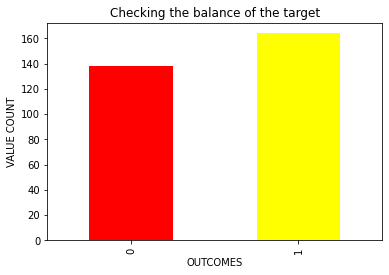

In [16]:
#checking balancing and unbalancing
DiseaseData['target'].value_counts().sort_values().plot(kind='bar',color=['red','yellow'])
plt.title("Checking the balance of the target")
plt.xlabel("OUTCOMES")
plt.ylabel("VALUE COUNT")
plt.show()

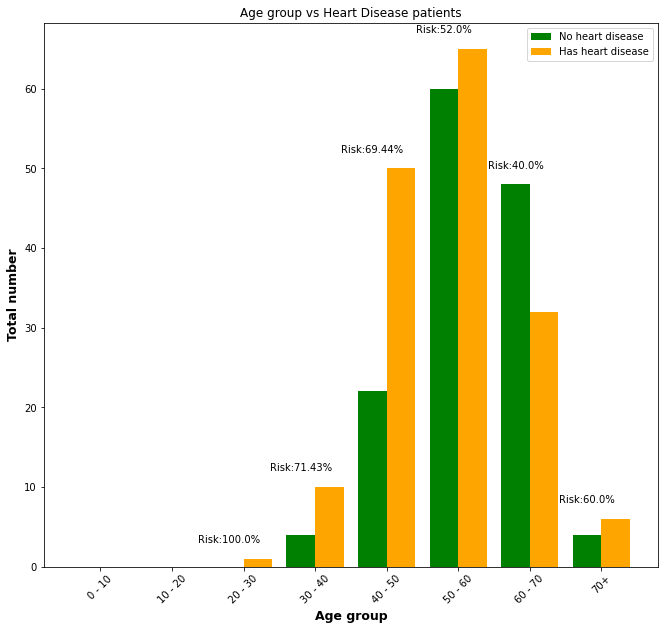

In [17]:
plt.figure(figsize=(11,10))
TargetAxis0 = dict(DiseaseData[DiseaseData['target']==0]['age'].value_counts())
TargetAxis1 = dict(DiseaseData[DiseaseData['target']==1]['age'].value_counts())
Grouping = ["0 - 10","10 - 20","20 - 30","30 - 40","40 - 50", "50 - 60", "60 - 70", "70+"]
def get_group(x):
    if x > 70:
        return Grouping[-1]
    else:
        return Grouping[x // 10]
group_count0 = {}
group_count1 = {}
for i in Grouping:
    group_count0[i] = 0
    group_count1[i] = 0
for i in TargetAxis0:
    group_count0[get_group(i)] += TargetAxis0[i]
for i in TargetAxis1:
    group_count1[get_group(i)] += TargetAxis1[i]
TargetAxis0 = group_count0
TargetAxis1 = group_count1
barWidth = 0.4
PosIndex0 = np.arange(len(TargetAxis0))
PosIndex1 = np.array([x + barWidth for x in PosIndex0])
plt.bar(PosIndex0,TargetAxis0.values(),width=barWidth,label='No heart disease',color='green')
plt.bar(PosIndex1,TargetAxis1.values(),width=barWidth,label='Has heart disease',color='orange')
plt.xticks([x + barWidth/2 for x in PosIndex0],Grouping,rotation = 45)
for i in range(len(Grouping)):
    total = TargetAxis0[Grouping[i]] + TargetAxis1[Grouping[i]]
    if total > 0:
        percent = round((TargetAxis1[Grouping[i]] / total) * 100,2)       
        plt.text(i,max(TargetAxis0[Grouping[i]], TargetAxis1[Grouping[i]]) + 2,"Risk:"+str(percent)+"%",ha='center')
plt.xlabel("Age group",fontweight='bold',fontsize=12.5)
plt.ylabel("Total number",fontweight='bold',fontsize=12.5)
plt.legend()
plt.title("Age group vs Heart Disease patients")
plt.show()

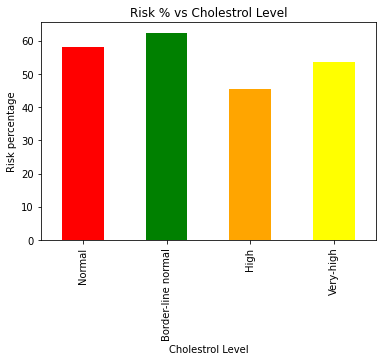

In [18]:
Level = [0,200,240,300,600]
Label = ['Normal','Border-line normal','High','Very-high']
DiseaseData['Chol_Level'] = pd.cut(DiseaseData['chol'],bins=Level,labels=Label)
grouped_value_summary = DiseaseData.groupby('Chol_Level')['target']
x = grouped_value_summary.mean() * 100
x.plot(kind='bar',color=['red','green','orange','yellow'])
plt.xlabel('Cholestrol Level')
plt.ylabel('Risk percentage')
plt.title('Risk % vs Cholestrol Level')
plt.show()

In [19]:
DiseaseData = DiseaseData.drop(['Chol_Level'], axis = 1)

In [20]:
DiseaseData.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


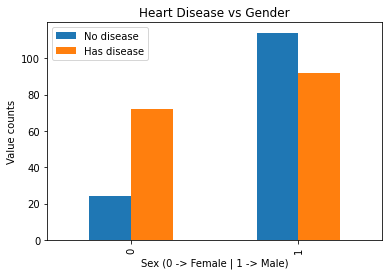

In [21]:
B0 = DiseaseData[DiseaseData['target'] == 0]['sex'].value_counts().sort_index()
B1 = DiseaseData[DiseaseData['target'] == 1]['sex'].value_counts().sort_index()
GRAPH_DF = pd.DataFrame({'No disease': B0, 'Has disease': B1})
GRAPH_DF.plot(kind='bar')
plt.xlabel('Sex (0 -> Female | 1 -> Male)')
plt.ylabel('Value counts')
plt.title("Heart Disease vs Gender")
plt.show()

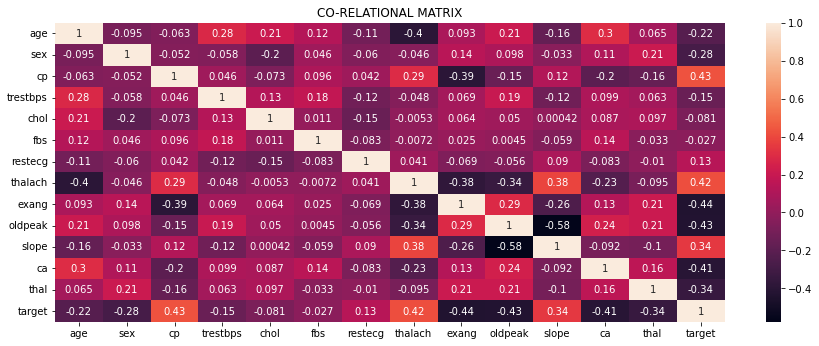

In [22]:
plt.figure(figsize=(15,5.5))
x = DiseaseData.corr()
sns.heatmap(x,annot=True)
plt.title("CO-RELATIONAL MATRIX")
plt.show()

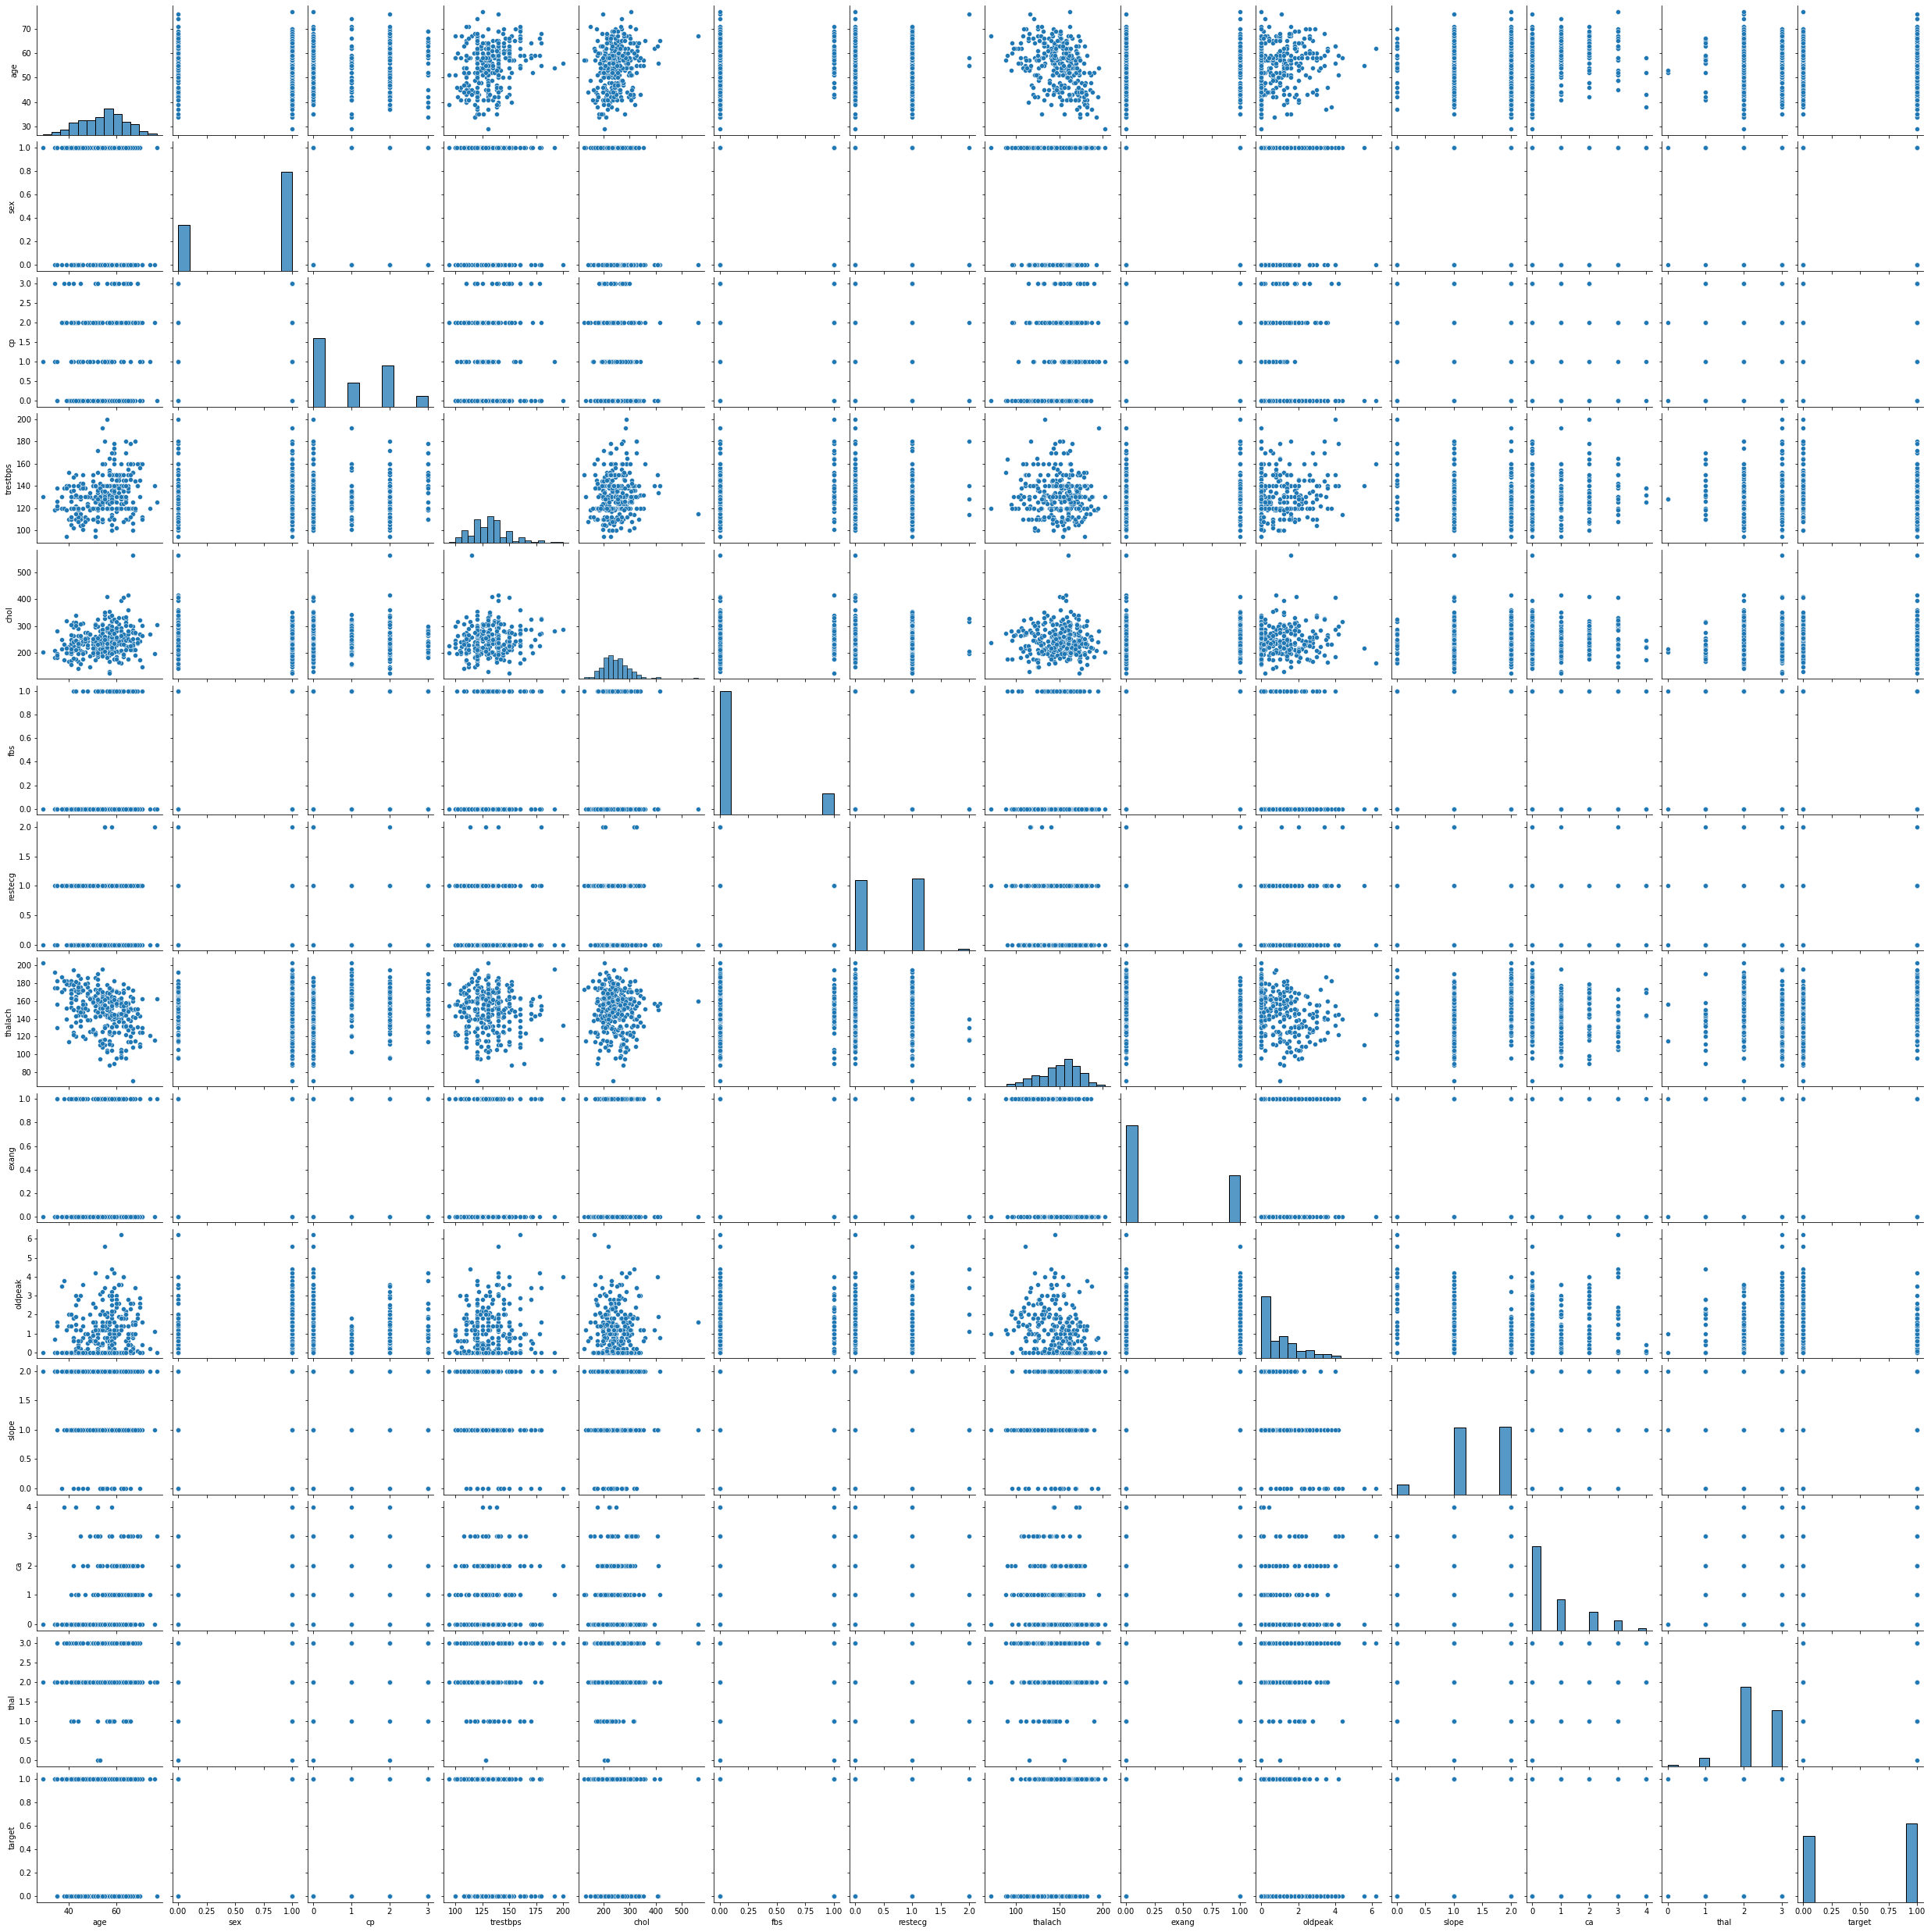

In [23]:
sns.pairplot(DiseaseData)
plt.show()

In [24]:
x, y = PANDAS_to_NUMPY(DiseaseData)

In [25]:
print(x)

[[52.  1.  0. ...  2.  2.  3.]
 [53.  1.  0. ...  0.  0.  3.]
 [70.  1.  0. ...  0.  0.  3.]
 ...
 [52.  1.  0. ...  2.  1.  3.]
 [59.  1.  3. ...  2.  0.  2.]
 [54.  1.  0. ...  1.  1.  3.]]


In [26]:
print(y)

[0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1
 0 1 1 0 1 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 0 1 0
 0 1 0 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 1 1 1
 0 1 1 0 0 0 1 1 0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 1 0 1 1 0 0 0 0 1 0 1
 1 0 0 1 1 1 0 0 1 1 0 1 1 1 0 1 0 0 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1
 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 1
 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 1 1 0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1
 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 1
 0 1 1 0 0 0]


In [27]:
MODEL = {
    'Model-Name' : [],
    'Accuracy-Score' : [],
    'Precision-Score' : [],
    'Recall-Score' : [],
    'F1-Score' : []
}

In [28]:
x_train, x_test, y_train, y_test = DATA_SPLIT(x,y)

In [29]:
x_train[::,[0, 3, 4,7]] = SC.fit_transform(x_train[::,[0, 3, 4,7]]).copy()
x_test[::,[0, 3, 4,7]] = SC.fit_transform(x_test[::,[0, 3, 4,7]]).copy()

In [30]:
print(x_train.shape[0] + x_test.shape[0] == x.shape[0], y_train.shape[0] + y_test.shape[0] == y.shape[0])

True True


In [31]:
KNN.fit(x_train,y_train)

KNeighborsClassifier()

In [32]:
y_pred_1 = KNN.predict(x_test)

In [33]:
MODEL['Model-Name'].append('K-Nearest Neighbors (n = 5)')
MODEL['Accuracy-Score'].append(accuracy_score(y_test,y_pred_1))
MODEL['Precision-Score'].append(precision_score(y_test,y_pred_1))
MODEL['Recall-Score'].append(recall_score(y_test,y_pred_1))
MODEL['F1-Score'].append(f1_score(y_test,y_pred_1))

In [34]:
print(MODEL)

{'Model-Name': ['K-Nearest Neighbors (n = 5)'], 'Accuracy-Score': [0.6885245901639344], 'Precision-Score': [0.6470588235294118], 'Recall-Score': [0.7586206896551724], 'F1-Score': [0.6984126984126984]}


In [35]:
LR.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [36]:
y_pred_2 = LR.predict(x_test)

In [37]:
MODEL['Model-Name'].append('LogisticRegression (max_iter = 1000)')
MODEL['Accuracy-Score'].append(accuracy_score(y_test,y_pred_2))
MODEL['Precision-Score'].append(precision_score(y_test,y_pred_2))
MODEL['Recall-Score'].append(recall_score(y_test,y_pred_2))
MODEL['F1-Score'].append(f1_score(y_test,y_pred_2))

In [46]:
MODEL_DF = pd.DataFrame(MODEL)

In [39]:
CONFUSION_MATRIX_KNN = confusion_matrix(y_test,y_pred_1)

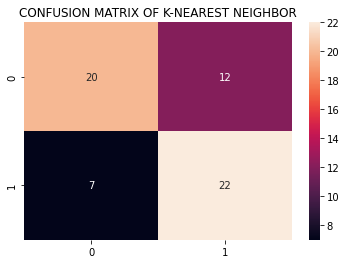

In [41]:
sns.heatmap(CONFUSION_MATRIX_KNN,annot=True)
plt.title("CONFUSION MATRIX OF K-NEAREST NEIGHBOR")
plt.show()

In [42]:
CONFUSION_MATRIX_LR = confusion_matrix(y_test,y_pred_2)

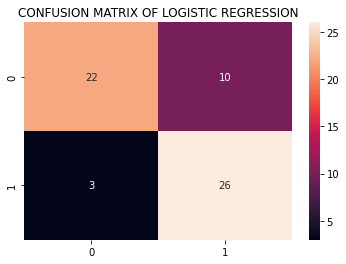

In [43]:
sns.heatmap(CONFUSION_MATRIX_LR,annot=True)
plt.title("CONFUSION MATRIX OF LOGISTIC REGRESSION")
plt.show()

In [44]:
print("Classification Report of K-Nearest Neighbor")
print(classification_report(y_test,y_pred_1))

Classification Report of K-Nearest Neighbor
              precision    recall  f1-score   support

           0       0.74      0.62      0.68        32
           1       0.65      0.76      0.70        29

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.70      0.69      0.69        61



In [45]:
print("Classification Report of Logistic Regression")
print(classification_report(y_test,y_pred_2))

Classification Report of Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.69      0.77        32
           1       0.72      0.90      0.80        29

    accuracy                           0.79        61
   macro avg       0.80      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



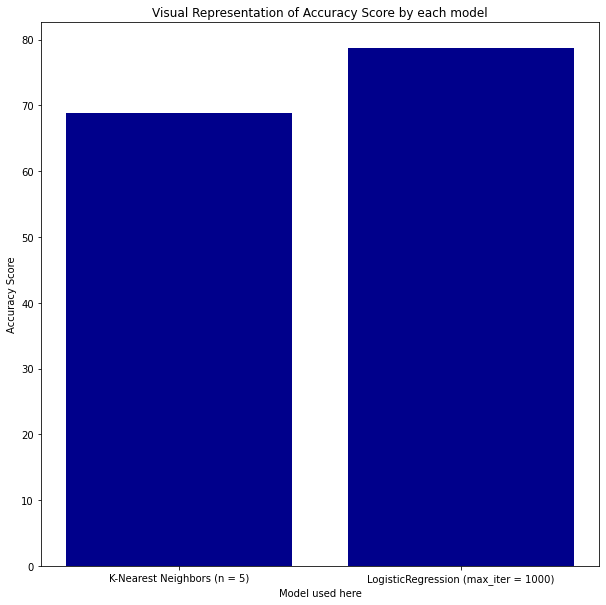

In [55]:
plt.figure(figsize=(10,10))
plt.bar(MODEL['Model-Name'],[x * 100 for x in MODEL['Accuracy-Score']], color='#00008B')
plt.xlabel('Model used here')
plt.ylabel('Accuracy Score')
plt.title("Visual Representation of Accuracy Score by each model")
plt.show()

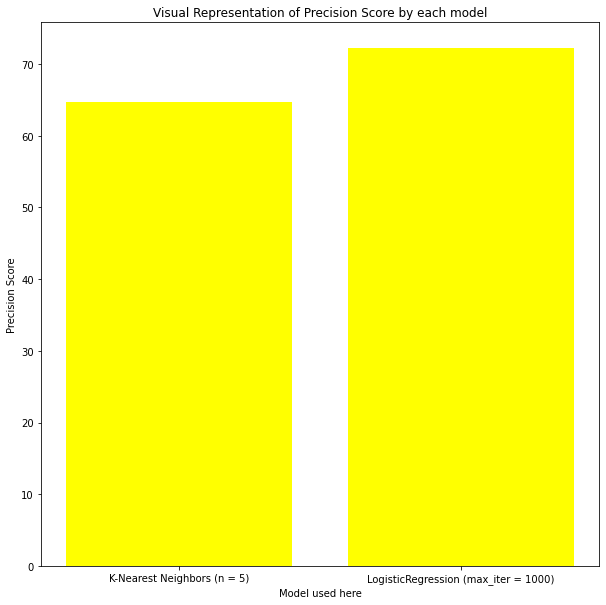

In [56]:
plt.figure(figsize=(10,10))
plt.bar(MODEL['Model-Name'],[x * 100 for x in MODEL['Precision-Score']], color='yellow')
plt.xlabel('Model used here')
plt.ylabel('Precision Score')
plt.title("Visual Representation of Precision Score by each model")
plt.show()

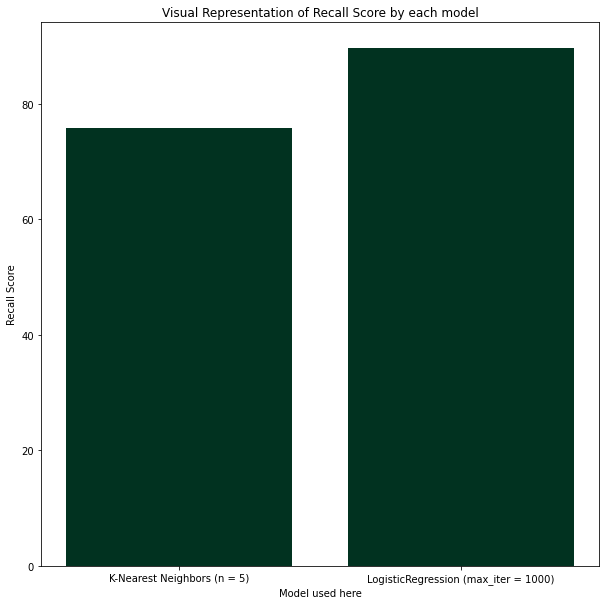

In [57]:
plt.figure(figsize=(10,10))
plt.bar(MODEL['Model-Name'],[x * 100 for x in MODEL['Recall-Score']], color='#013220')
plt.xlabel('Model used here')
plt.ylabel('Recall Score')
plt.title("Visual Representation of Recall Score by each model")
plt.show()

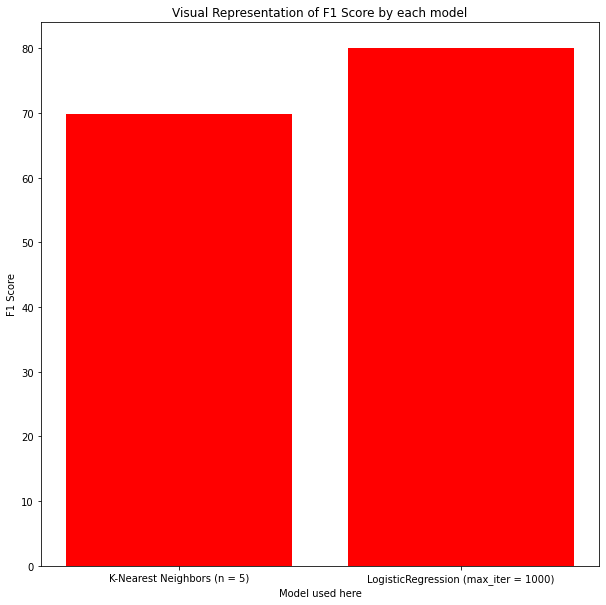

In [58]:
plt.figure(figsize=(10,10))
plt.bar(MODEL['Model-Name'],[x * 100 for x in MODEL['F1-Score']], color='red')
plt.xlabel('Model used here')
plt.ylabel('F1 Score')
plt.title("Visual Representation of F1 Score by each model")
plt.show()

In [59]:
#SUMMARY THIS PROJECT DEMONSTRATES EXPLORATORY DATA ANALYSIS ON THE PAST RECORD OF HEART DISEASE DATASET AND PREDICTS WHETHER A PATIENT HAS ANY HEART DISEASE OR NOT
#SINCE THIS PROJECT IS ON INITIAL STAGE SO MANY MORE FEATURES WILL BE ADD SUCH AS USER INTERFACE ADVANCE AIML ALGORITHMS 
#FURTHERMOST EVEN RECOMENDATION OF MEDICINE CAN BE ADDED HERE